# Apartado 1 - Contexto del Proceso de Ingesta

En este primer apartado se establece el objetivo de la fase inicial del ETL: preparar la sesion de Spark, definir un esquema explicito y garantizar que la lectura del dataset se haga con validaciones de estructura y tipos.

Esto reduce errores silenciosos en etapas posteriores del analisis y del modelado.

## Apartado 2 - Inicializacion de SparkSession

En este apartado se crea una sesion de Spark robusta para ejecutar el pipeline tanto en local como en remoto. Tambien se limpia cualquier sesion previa para evitar conflictos y se valida la conectividad con el master cuando corresponde.

In [1]:
# Paso 2 - Inicializacion de SparkSession
import os
import socket
from urllib.parse import urlparse

from pyspark.sql import SparkSession

# Limpiar cualquier sesión anterior detenida
active_session = SparkSession.getActiveSession()
if active_session is not None:
    try:
        active_session.stop()
    except:
        pass

master_url = os.getenv("SPARK_MASTER", "spark://spark-master:7077")
use_remote_master = os.getenv("SPARK_USE_REMOTE_MASTER", "").strip().lower() in {"1", "true", "yes"}


def master_is_reachable(master: str) -> bool:
    parsed = urlparse(master)
    if parsed.scheme != "spark" or not parsed.hostname or not parsed.port:
        return False
    try:
        with socket.create_connection((parsed.hostname, parsed.port), timeout=2):
            return True
    except OSError:
        return False


spark_master = master_url if use_remote_master and master_is_reachable(master_url) else "local[*]"
if spark_master == "local[*]":
    print("Using local[*] so the smoke test does not depend on remote worker Python versions.")
else:
    print(f"Using remote Spark master: {spark_master}")

spark = (SparkSession.builder
         .appName("IABurnout-Spark-Smoke-Test")
         .master(spark_master)
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Spark master: {spark.sparkContext.master}")

Using local[*] so the smoke test does not depend on remote worker Python versions.
Spark version: 4.1.1
Spark master: local[*]


## Apartado 3 - Definicion del Esquema de Datos

En este apartado se declara el esquema esperado del dataset con tipos explicitos por columna. Esto permite controlar la calidad de la ingesta y asegura consistencia para transformaciones, feature engineering y entrenamiento futuro de modelos.

In [2]:
# Paso 3 - Definicion del Esquema Estructurado
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType
)

schema = StructType([
    StructField("record_id", StringType(), True),
    StructField("year", IntegerType(), True),
    StructField("country", StringType(), True),
    StructField("industry", StringType(), True),
    StructField("job_role", StringType(), True),
    StructField("employment_type", StringType(), True),
    StructField("work_model", StringType(), True),
    StructField("company_size", StringType(), True),
    StructField("age_group", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("years_of_experience", IntegerType(), True),
    StructField("annual_salary_usd", IntegerType(), True),
    StructField("weekly_work_hours", IntegerType(), True),
    StructField("weekly_overtime_hours", IntegerType(), True),
    StructField("mental_health_condition", StringType(), True),
    StructField("has_diagnosis", StringType(), True),
    StructField("treatment_type", StringType(), True),
    StructField("stress_level", StringType(), True),
    StructField("burnout_risk_score", DoubleType(), True),
    StructField("work_life_balance_score", DoubleType(), True),
    StructField("productivity_score", DoubleType(), True),
    StructField("job_satisfaction_score", DoubleType(), True),
    StructField("absenteeism_days_per_year", IntegerType(), True),
    StructField("employer_support_level", StringType(), True),
    StructField("mental_health_policy_exists", StringType(), True),
    StructField("eap_available", StringType(), True),
    StructField("used_eap", StringType(), True),
    StructField("workplace_stigma_felt", StringType(), True),
    StructField("manager_support_score", DoubleType(), True),
    StructField("team_collaboration_score", DoubleType(), True),
    StructField("intention_to_leave", StringType(), True),
    StructField("remote_work_preference", StringType(), True),
    StructField("exercise_days_per_week", IntegerType(), True),
    StructField("sleep_hours_per_night", DoubleType(), True),
])

print(f"Esquema definido con {len(schema.fields)} columnas")

Esquema definido con 34 columnas


In [3]:
from pathlib import Path
import os

# Función para buscar recursivamente hacia arriba hasta encontrar la carpeta 'data'
def find_data_file(filename="mental_health_workplace.csv", max_depth=5):
    """Busca el archivo CSV subiendo en el árbol de directorios."""
    current = Path.cwd()
    for _ in range(max_depth):
        candidate = current / "data" / filename
        if candidate.exists():
            return candidate
        current = current.parent
    return None

# Intenta 1: Búsqueda recursiva desde el directorio actual
dataset_path = find_data_file()

# Intenta 2: Si está en un contenedor Docker, busca en rutas comunes de montaje
if dataset_path is None:
    for docker_mount in ["/work", "/workspace", "/app", "/home/jovyan/work"]:
        candidate = Path(docker_mount) / "data" / "mental_health_workplace.csv"
        if candidate.exists():
            dataset_path = candidate
            break

# Intenta 3: Si SPARK_HOME está configurado, búsqueda desde ahí
if dataset_path is None:
    spark_home = os.getenv("SPARK_HOME")
    if spark_home:
        current = Path(spark_home)
        for _ in range(5):
            candidate = current / "data" / "mental_health_workplace.csv"
            if candidate.exists():
                dataset_path = candidate
                break
            current = current.parent

if dataset_path is None:
    # Debug: mostrar donde estamos buscando
    print(f"❌ No se encontró el archivo!")
    print(f"Directorio de trabajo actual: {Path.cwd()}")
    print(f"SPARK_HOME: {os.getenv('SPARK_HOME', 'No configurado')}")
    print(f"\nIntentando listar directorios:")
    for d in [Path.cwd(), Path.cwd().parent, Path("/work"), Path("/workspace")]:
        if d.exists():
            print(f"\n  {d}:")
            try:
                items = sorted(d.iterdir())[:10]
                for item in items:
                    print(f"    - {item.name}{'/' if item.is_dir() else ''}")
            except PermissionError:
                print(f"    (sin permisos)")
    raise FileNotFoundError(
        "No se encontro mental_health_workplace.csv. "
        "Verifica que el archivo esté en data/ dentro del proyecto."
    )

dataset_path = str(dataset_path)
print(f"✓ Archivo encontrado: {dataset_path}")

df_burnout = (
    spark.read
    .option("header", "true")
    .option("mode", "FAILFAST")
    .schema(schema)
    .csv(dataset_path)
)

expected_schema = [(f.name, f.dataType.simpleString()) for f in schema.fields]
actual_schema = [(f.name, f.dataType.simpleString()) for f in df_burnout.schema.fields]

if expected_schema != actual_schema:
    actual_schema_dict = dict(actual_schema)
    expected_schema_dict = dict(expected_schema)
    missing = [c for c, _ in expected_schema if c not in actual_schema_dict]
    unexpected = [c for c, _ in actual_schema if c not in expected_schema_dict]
    type_mismatch = [
        (name, exp_t, actual_schema_dict.get(name))
        for name, exp_t in expected_schema
        if name in actual_schema_dict and actual_schema_dict[name] != exp_t
    ]
    raise ValueError(
        "Esquema invalido tras ingesta. "
        f"Faltantes: {missing}. "
        f"Sobrantes: {unexpected}. "
        f"Tipos distintos: {type_mismatch}"
    )

print(f"Dataset cargado correctamente desde: {dataset_path}")
print(f"Filas: {df_burnout.count()} | Columnas: {len(df_burnout.columns)}")
df_burnout.printSchema()
df_burnout.show(5, truncate=False)

✓ Archivo encontrado: /data/mental_health_workplace.csv
Dataset cargado correctamente desde: /data/mental_health_workplace.csv
Filas: 10000 | Columnas: 34
root
 |-- record_id: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- employment_type: string (nullable = true)
 |-- work_model: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- years_of_experience: integer (nullable = true)
 |-- annual_salary_usd: integer (nullable = true)
 |-- weekly_work_hours: integer (nullable = true)
 |-- weekly_overtime_hours: integer (nullable = true)
 |-- mental_health_condition: string (nullable = true)
 |-- has_diagnosis: string (nullable = true)
 |-- treatment_type: string (nullable = true)
 |-- stress_level: string (nullable = true)
 |-- burnout_risk_score: double (nu

## ETL 1 - Analisis de Datos Faltantes

Calculamos cantidad y porcentaje de valores nulos por columna para priorizar limpieza y decisiones de modelado.

In [4]:
from pyspark.sql import functions as F

row_count = df_burnout.count()

missing_stats = (
    df_burnout
    .select([
        F.sum(F.col(c).isNull().cast("int")).alias(c)
        for c in df_burnout.columns
    ])
)

missing_long = (
    missing_stats
    .select(
        F.explode(
            F.array([
                F.struct(
                    F.lit(c).alias("column"),
                    F.col(c).cast("long").alias("missing_count")
                )
                for c in df_burnout.columns
            ])
        ).alias("kv")
    )
    .select(
        F.col("kv.column").alias("column"),
        F.col("kv.missing_count").alias("missing_count")
    )
    .withColumn(
        "missing_pct",
        F.when(F.lit(row_count) > 0, F.round((F.col("missing_count") / F.lit(row_count)) * 100, 2))
         .otherwise(F.lit(0.0))
    )
    .orderBy(F.desc("missing_pct"), F.desc("missing_count"))
)

print(f"Total de filas evaluadas: {row_count}")
missing_long.show(len(df_burnout.columns), truncate=False)

Total de filas evaluadas: 10000
+---------------------------+-------------+-----------+
|column                     |missing_count|missing_pct|
+---------------------------+-------------+-----------+
|record_id                  |0            |0.0        |
|year                       |0            |0.0        |
|country                    |0            |0.0        |
|industry                   |0            |0.0        |
|job_role                   |0            |0.0        |
|employment_type            |0            |0.0        |
|work_model                 |0            |0.0        |
|company_size               |0            |0.0        |
|age_group                  |0            |0.0        |
|gender                     |0            |0.0        |
|years_of_experience        |0            |0.0        |
|annual_salary_usd          |0            |0.0        |
|weekly_work_hours          |0            |0.0        |
|weekly_overtime_hours      |0            |0.0        |
|mental_health_c

## ETL 2 - Limpieza de Registros Incompletos

Eliminamos filas con al menos un valor nulo para quedarnos con registros completos.

In [5]:
rows_before = df_burnout.count()

# Drop de cualquier fila con null en alguna columna
# Si quieres una regla menos estricta, luego podemos usar un subconjunto de columnas criticas.
df_clean = df_burnout.dropna(how="any")

rows_after = df_clean.count()
rows_removed = rows_before - rows_after

print(f"Filas antes de limpieza: {rows_before}")
print(f"Filas despues de limpieza: {rows_after}")
print(f"Filas eliminadas por datos faltantes: {rows_removed}")

Filas antes de limpieza: 10000
Filas despues de limpieza: 10000
Filas eliminadas por datos faltantes: 0


## ETL 3 - Parseo y Normalizacion de Tipos

Estandarizamos columnas de texto y reforzamos cast explicito en variables numericas.

In [6]:
from pyspark.sql.types import IntegerType, DoubleType, StringType

numeric_int_cols = [
    "year", "years_of_experience", "annual_salary_usd", "weekly_work_hours",
    "weekly_overtime_hours", "absenteeism_days_per_year", "exercise_days_per_week"
]

numeric_double_cols = [
    "burnout_risk_score", "work_life_balance_score", "productivity_score",
    "job_satisfaction_score", "manager_support_score",
    "team_collaboration_score", "sleep_hours_per_night"
]

string_cols = [f.name for f in df_clean.schema.fields if isinstance(f.dataType, StringType)]

df_typed = df_clean

for c in numeric_int_cols:
    df_typed = df_typed.withColumn(c, F.col(c).cast(IntegerType()))

for c in numeric_double_cols:
    df_typed = df_typed.withColumn(c, F.col(c).cast(DoubleType()))

for c in string_cols:
    df_typed = df_typed.withColumn(c, F.trim(F.lower(F.col(c))))

print("Esquema despues de parseo/normalizacion:")
df_typed.printSchema()

Esquema despues de parseo/normalizacion:
root
 |-- record_id: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- employment_type: string (nullable = true)
 |-- work_model: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- years_of_experience: integer (nullable = true)
 |-- annual_salary_usd: integer (nullable = true)
 |-- weekly_work_hours: integer (nullable = true)
 |-- weekly_overtime_hours: integer (nullable = true)
 |-- mental_health_condition: string (nullable = true)
 |-- has_diagnosis: string (nullable = true)
 |-- treatment_type: string (nullable = true)
 |-- stress_level: string (nullable = true)
 |-- burnout_risk_score: double (nullable = true)
 |-- work_life_balance_score: double (nullable = true)
 |-- productivity_score: double (nullable = 

## ETL 4 - Feature Engineering

Construimos variables derivadas para capturar intensidad de carga laboral, compensacion y factores de soporte.

In [7]:
df_features = (
    df_typed
    .withColumn(
        "total_weekly_load",
        F.col("weekly_work_hours") + F.col("weekly_overtime_hours")
    )
    .withColumn(
        "overtime_ratio",
        F.when(F.col("weekly_work_hours") > 0,
               F.round(F.col("weekly_overtime_hours") / F.col("weekly_work_hours"), 4))
         .otherwise(F.lit(0.0))
    )
    .withColumn(
        "salary_per_hour_est",
        F.when(F.col("weekly_work_hours") > 0,
               F.round(F.col("annual_salary_usd") / (F.col("weekly_work_hours") * F.lit(52.0)), 2))
         .otherwise(F.lit(None).cast(DoubleType()))
    )
    .withColumn(
        "is_remote_preference",
        F.when(F.col("remote_work_preference").isin("yes", "si", "true", "1"), F.lit(1)).otherwise(F.lit(0))
    )
    .withColumn(
        "has_mental_health_diagnosis",
        F.when(F.col("has_diagnosis").isin("yes", "si", "true", "1"), F.lit(1)).otherwise(F.lit(0))
    )
)

print("Vista rapida de features nuevas:")
df_features.select(
    "record_id", "total_weekly_load", "overtime_ratio", "salary_per_hour_est",
    "is_remote_preference", "has_mental_health_diagnosis"
).show(5, truncate=False)

Vista rapida de features nuevas:
+----------+-----------------+--------------+-------------------+--------------------+---------------------------+
|record_id |total_weekly_load|overtime_ratio|salary_per_hour_est|is_remote_preference|has_mental_health_diagnosis|
+----------+-----------------+--------------+-------------------+--------------------+---------------------------+
|mhw0000001|40               |0.0           |30.43              |0                   |1                          |
|mhw0000002|38               |0.0           |32.6               |0                   |1                          |
|mhw0000003|40               |0.0           |60.2               |0                   |1                          |
|mhw0000004|38               |0.0           |23.41              |0                   |0                          |
|mhw0000005|66               |0.2453        |34.54              |0                   |1                          |
+----------+-----------------+--------------+--

## ETL 5 - Seleccion de Columnas para Modelado Futuro

Definimos una vista limpia de variables predictoras y la variable objetivo para un pipeline de ML posterior.

In [8]:
target_col = "burnout_risk_score"

model_feature_cols = [
    "year",
    "industry",
    "job_role",
    "employment_type",
    "work_model",
    "company_size",
    "age_group",
    "gender",
    "years_of_experience",
    "annual_salary_usd",
    "weekly_work_hours",
    "weekly_overtime_hours",
    "stress_level",
    "work_life_balance_score",
    "productivity_score",
    "job_satisfaction_score",
    "absenteeism_days_per_year",
    "employer_support_level",
    "mental_health_policy_exists",
    "eap_available",
    "workplace_stigma_felt",
    "manager_support_score",
    "team_collaboration_score",
    "exercise_days_per_week",
    "sleep_hours_per_night",
    "total_weekly_load",
    "overtime_ratio",
    "salary_per_hour_est",
    "is_remote_preference",
    "has_mental_health_diagnosis"
]

selected_cols = ["record_id"] + model_feature_cols + [target_col]

df_model = df_features.select(*selected_cols).dropna(how="any")

print(f"Columnas seleccionadas para modelado: {len(selected_cols)}")
print(f"Filas finales en df_model: {df_model.count()}")
df_model.printSchema()
df_model.show(5, truncate=False)

Columnas seleccionadas para modelado: 32
Filas finales en df_model: 10000
root
 |-- record_id: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- industry: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- employment_type: string (nullable = true)
 |-- work_model: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- years_of_experience: integer (nullable = true)
 |-- annual_salary_usd: integer (nullable = true)
 |-- weekly_work_hours: integer (nullable = true)
 |-- weekly_overtime_hours: integer (nullable = true)
 |-- stress_level: string (nullable = true)
 |-- work_life_balance_score: double (nullable = true)
 |-- productivity_score: double (nullable = true)
 |-- job_satisfaction_score: double (nullable = true)
 |-- absenteeism_days_per_year: integer (nullable = true)
 |-- employer_support_level: string (nullable = true)
 |-- mental_health_policy_exis

## ETL 6 - Transformaciones para Machine Learning

Preparamos el dataset con indexado, codificacion one-hot, ensamblado de features y escalado para dejarlo listo para futuros modelos de regresion o clasificacion.

In [9]:
from pyspark.sql.types import StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

label_col = target_col

categorical_cols = [
    field.name
    for field in df_model.schema.fields
    if isinstance(field.dataType, StringType) and field.name not in {"record_id", label_col}
]

numeric_cols = [
    field.name
    for field in df_model.schema.fields
    if field.name not in {"record_id", label_col} and field.name not in categorical_cols
]

indexer_stages = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_cols],
    outputCols=[f"{c}_ohe" for c in categorical_cols],
    handleInvalid="keep"
)

assembler_inputs = numeric_cols + [f"{c}_ohe" for c in categorical_cols]
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=False
)

ml_pipeline = Pipeline(stages=indexer_stages + [encoder, assembler, scaler])
ml_pipeline_model = ml_pipeline.fit(df_model)

df_ml_ready = ml_pipeline_model.transform(df_model)

print(f"Columnas categoricas indexadas: {len(categorical_cols)}")
print(f"Columnas numericas usadas directamente: {len(numeric_cols)}")
print("Esquema del dataset preparado para ML:")
df_ml_ready.select("record_id", label_col, "features_raw", "features_scaled").printSchema()
print("Vista previa del dataset preparado para ML:")
df_ml_ready.select("record_id", label_col, "features_raw", "features_scaled").show(5, truncate=False)

Columnas categoricas indexadas: 12
Columnas numericas usadas directamente: 18
Esquema del dataset preparado para ML:
root
 |-- record_id: string (nullable = true)
 |-- burnout_risk_score: double (nullable = true)
 |-- features_raw: vector (nullable = true)
 |-- features_scaled: vector (nullable = true)

Vista previa del dataset preparado para ML:
+----------+------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## ETL 7 - Evaluacion de Calidad y Optimización Futura

Analizamos cardinalidad, correlacion con la variable objetivo y posibles riesgos de modelado para priorizar mejoras antes de entrenar un modelo.

In [10]:
from pyspark.sql import functions as F

row_total = df_ml_ready.count()
distinct_records = df_ml_ready.select("record_id").distinct().count()
duplicate_records = row_total - distinct_records

target_summary = df_ml_ready.select(target_col).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")

stddev_row = df_ml_ready.select(
    *[F.stddev(F.col(c)).alias(c) for c in numeric_cols + [target_col]]
).first().asDict()

target_stddev = stddev_row.get(target_col)
correlation_rows = []
skipped_corr_cols = []

for column_name in numeric_cols:
    column_stddev = stddev_row.get(column_name)
    if column_stddev in (None, 0) or target_stddev in (None, 0):
        skipped_corr_cols.append(column_name)
        correlation_rows.append((column_name, None))
        continue

    correlation_rows.append(
        (
            column_name,
            df_ml_ready.stat.corr(column_name, target_col)
        )
    )

correlation_df = spark.createDataFrame(correlation_rows, ["feature", "corr_with_target"]) \
    .withColumn("abs_corr", F.abs(F.col("corr_with_target"))) \
    .orderBy(F.desc("abs_corr"))

cardinality_rows = []
for column_name in categorical_cols:
    cardinality_rows.append(
        (
            column_name,
            df_ml_ready.select(column_name).distinct().count()
        )
    )

cardinality_df = spark.createDataFrame(cardinality_rows, ["feature", "distinct_values"]) \
    .orderBy(F.desc("distinct_values"))

print(f"Filas totales evaluadas: {row_total}")
print(f"Registros duplicados por record_id: {duplicate_records}")
print("\nResumen estadistico de la variable objetivo:")
target_summary.show(truncate=False)
print("\nTop correlaciones absolutas con la variable objetivo:")
correlation_df.show(len(correlation_rows), truncate=False)
print("\nCardinalidad de variables categoricas:")
cardinality_df.show(len(cardinality_rows), truncate=False)

high_cardinality = cardinality_df.filter(F.col("distinct_values") >= 10).count()
low_signal = correlation_df.filter(F.col("abs_corr") < 0.05).count()

print(f"Variables categoricas con cardinalidad alta (>= 10): {high_cardinality}")
print(f"Variables numericas con baja correlacion con el target (< 0.05): {low_signal}")
if skipped_corr_cols:
    print(f"Columnas omitidas en correlacion por desviacion cero o nula: {skipped_corr_cols}")
print("Sugerencia: priorizar revision de cardinalidad alta y probar seleccion de variables con mayor correlacion para futuros modelos.")

Filas totales evaluadas: 10000
Registros duplicados por record_id: 0

Resumen estadistico de la variable objetivo:
+-------+------------------+
|summary|burnout_risk_score|
+-------+------------------+
|count  |10000             |
|mean   |4.027030000000008 |
|stddev |2.304457730496078 |
|min    |1.0               |
|25%    |2.2               |
|50%    |3.7               |
|75%    |5.5               |
|max    |10.0              |
+-------+------------------+


Top correlaciones absolutas con la variable objetivo:
+---------------------------+----------------------+---------------------+
|feature                    |corr_with_target      |abs_corr             |
+---------------------------+----------------------+---------------------+
|total_weekly_load          |0.7571538215414123    |0.7571538215414123   |
|weekly_work_hours          |0.7472051686101889    |0.7472051686101889   |
|weekly_overtime_hours      |0.7469118084035488    |0.7469118084035488   |
|overtime_ratio             |0.

## ETL 8 - Guardado del Dataset ML-Ready en Parquet Particionado

Se persiste el dataset ya transformado para machine learning en formato Parquet, particionado por columnas utiles para lecturas selectivas y pruebas posteriores.

In [11]:
from pathlib import Path

output_parquet_path = str((Path.cwd() / "output" / "burnout_ml_ready_parquet").resolve())

(
    df_ml_ready
    .write
    .mode("overwrite")
    .partitionBy("year", "industry")
    .parquet(output_parquet_path)
)

print(f"Dataset ML-ready guardado en: {output_parquet_path}")
print("Particiones usadas: year, industry")

Dataset ML-ready guardado en: /home/jovyan/work/notebooks/output/burnout_ml_ready_parquet
Particiones usadas: year, industry


## ETL 9 - Verificacion de Persistencia Parquet

Se recarga el Parquet generado, se valida conteo/esquema y se comprueba que el dataset transformado para ML pueda leerse correctamente.

In [12]:
df_ml_check = spark.read.parquet(output_parquet_path)

print(f"Filas verificadas desde parquet: {df_ml_check.count()}")
print(f"Columnas verificadas desde parquet: {len(df_ml_check.columns)}")

print("Esquema recargado:")
df_ml_check.printSchema()

print("Muestra de datos recargados:")
df_ml_check.select("record_id", target_col, "features_scaled").show(5, truncate=False)

print(f"Numero de archivos leidos: {len(df_ml_check.inputFiles())}")
print("Verificacion de consistencia entre escritura y lectura:")
print(f"- Coinciden las filas: {df_ml_check.count() == df_ml_ready.count()}")
print(f"- Coinciden las columnas: {set(df_ml_check.columns) == set(df_ml_ready.columns)}")

Filas verificadas desde parquet: 10000
Columnas verificadas desde parquet: 58
Esquema recargado:
root
 |-- record_id: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- employment_type: string (nullable = true)
 |-- work_model: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- years_of_experience: integer (nullable = true)
 |-- annual_salary_usd: integer (nullable = true)
 |-- weekly_work_hours: integer (nullable = true)
 |-- weekly_overtime_hours: integer (nullable = true)
 |-- stress_level: string (nullable = true)
 |-- work_life_balance_score: double (nullable = true)
 |-- productivity_score: double (nullable = true)
 |-- job_satisfaction_score: double (nullable = true)
 |-- absenteeism_days_per_year: integer (nullable = true)
 |-- employer_support_level: string (nullable = true)
 |-- mental_health_policy_exists: string (nullable = true)
 |-- eap_available: strin

## Modelado Predictivo - Clasificación de Burnout

En esta sección entrenamos modelos de clasificación para predecir cuándo un registro corresponde a `burnout` (variable binaria derivada de `burnout_risk_score`). Se incluyen métricas estándar, curvas ROC/PR, matriz de confusión y análisis de importancia de features.

In [13]:
# Requisitos: instala scikit-learn, matplotlib, seaborn y joblib si no están disponibles
try:
    import sklearn
except Exception:
    import sys
    print('Instalando dependencias...')
    !{sys.executable} -m pip install --quiet scikit-learn matplotlib seaborn joblib
    import sklearn
print('Imports listos')

Imports listos


In [14]:
# Cargamos el dataset ML-ready y creamos la variable objetivo binaria
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Umbral de burnout: percentil (por ejemplo 75%) para marcar casos de burnout alto
quantile = 0.75
threshold = df_ml_ready.approxQuantile('burnout_risk_score', [quantile], 0.01)[0]
print(f'Usando umbral de burnout (quantile={quantile}): {threshold}')

df_clf = df_ml_ready.withColumn('burnout', F.when(F.col('burnout_risk_score') >= F.lit(threshold), 1).otherwise(0).cast('int'))

# Convertimos el vector de features a array (necesario para pasar a pandas/sklearn)
df_for_pd = df_clf.select('record_id', 'burnout', vector_to_array('features_scaled').alias('features_array'))

# Muestreamos si el dataset es muy grande para acelerar entrenamiento local
max_samples = 20000
count_total = df_for_pd.count()
if count_total > max_samples:
    sample_frac = max_samples / float(count_total)
    print(f'Realizando muestreo aleatorio: {max_samples} de {count_total} registros (~{sample_frac:.3f})')
    df_for_pd = df_for_pd.sample(False, sample_frac, seed=42)

pdf = df_for_pd.toPandas()

# Expandimos la columna features_array a una matriz numpy
import numpy as np
X = np.vstack(pdf['features_array'].values) if len(pdf) > 0 else np.empty((0,0))
y = pdf['burnout'].values
print('Shapes -> X:', X.shape, 'y:', y.shape)

Usando umbral de burnout (quantile=0.75): 5.4
Shapes -> X: (10000, 105) y: (10000,)


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Resultados Logistic Regression ---
LR: Accuracy: 0.868 | Precision: 0.701 | Recall: 0.871 | F1: 0.777 | ROC-AUC: 0.948
--- Resultados Random Forest ---
RF: Accuracy: 0.882 | Precision: 0.836 | Recall: 0.688 | F1: 0.755 | ROC-AUC: 0.949


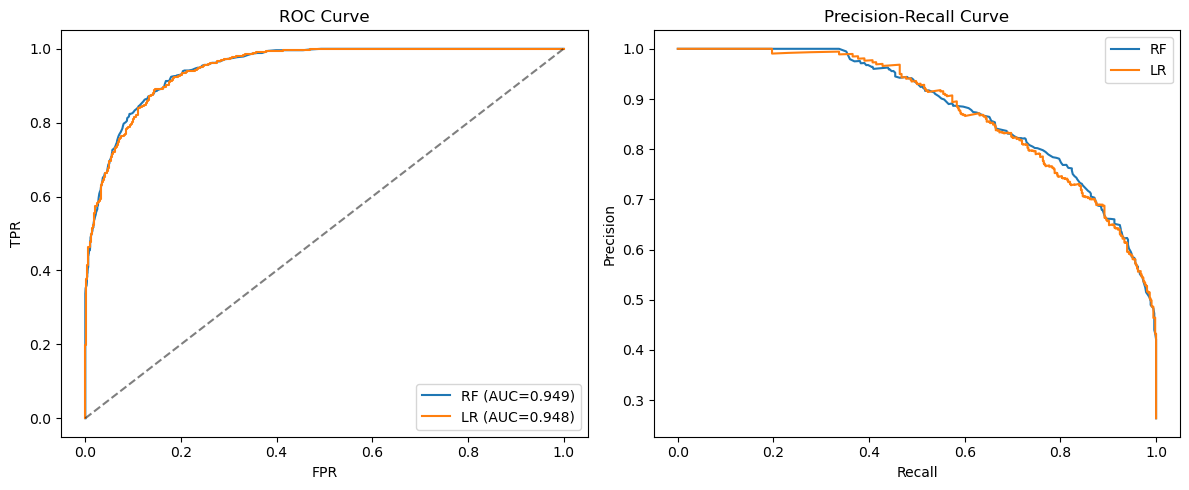

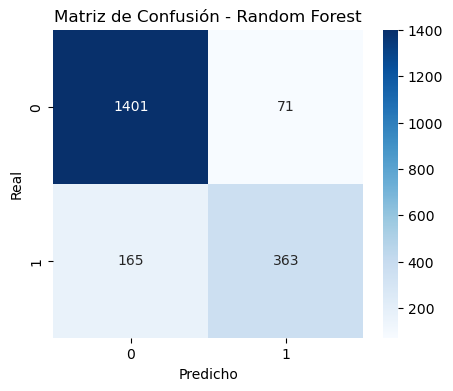

Top 15 features por importancia (Random Forest):


,feature,importance
0,weekly_work_hours,0.113150
1,total_weekly_load,0.108054
2,overtime_ratio,0.098619
3,weekly_overtime_hours,0.090806
4,absenteeism_days_per_year,0.079949
5,work_life_balance_score,0.066667
6,productivity_score,0.048757
7,has_mental_health_diagnosis,0.033440
8,salary_per_hour_est,0.027804
9,annual_salary_usd,0.027262


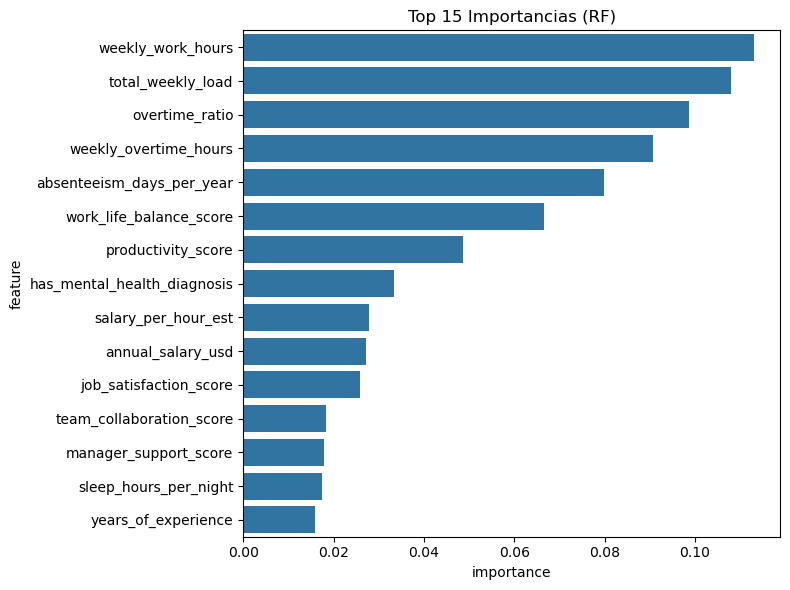

Top 15 features por coeficiente absoluto (Logistic Regression):


,feature,coef,abs_coef
0,overtime_ratio,-3.452524,3.452524
1,weekly_overtime_hours,2.691240,2.691240
2,total_weekly_load,2.146994,2.146994
3,weekly_work_hours,1.666571,1.666571
4,work_life_balance_score,-1.112125,1.112125
5,absenteeism_days_per_year,1.032223,1.032223
6,productivity_score,-0.536013,0.536013
7,has_mental_health_diagnosis,0.464511,0.464511
8,stress_level__ohe_3,0.346265,0.346265
9,stress_level__ohe_2,-0.337342,0.337342


Modelos guardados en: /home/jovyan/work/notebooks/output/models


In [15]:
# Entrenamiento: Logistic Regression y Random Forest (baseline)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# Si no hay suficientes datos, salir con mensaje
if X.shape[0] < 10:
    print('No hay suficientes registros para entrenar modelos. Revisa el dataset ML-ready.')
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # Logistic Regression (baseline)
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    y_proba_lr = lr.predict_proba(X_test)[:,1]

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:,1]

    # Metrics function
    def print_metrics(y_true, y_pred, y_proba, prefix=''):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_true, y_proba)
        except Exception:
            auc = float('nan')
        print(f'{prefix}Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

    print('--- Resultados Logistic Regression ---')
    print_metrics(y_test, y_pred_lr, y_proba_lr, prefix='LR: ')
    print('--- Resultados Random Forest ---')
    print_metrics(y_test, y_pred_rf, y_proba_rf, prefix='RF: ')

    # Curvas ROC y PR
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
    plt.plot(fpr, tpr, label=f'RF (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
    fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
    plt.plot(fpr, tpr, label=f'LR (AUC={roc_auc_score(y_test, y_proba_lr):.3f})')
    plt.plot([0,1],[0,1],'k--',alpha=0.5)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Curve')
    plt.legend()

    plt.subplot(1,2,2)
    prec, rec, _ = precision_recall_curve(y_test, y_proba_rf)
    plt.plot(rec, prec, label='RF')
    prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)
    plt.plot(rec, prec, label='LR')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Matriz de confusión para RF
    cm = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión - Random Forest')
    plt.show()

    # Importancia de features (RF) y coeficientes (LR)
    try:
        # Reconstruir nombres de features a partir del assembler y encoder si existen en el entorno
        feature_names = None
        if 'assembler' in globals() and 'categorical_cols' in globals():
            assembler_inputs = assembler.getInputCols()
            # Buscar OneHotEncoderModel en el pipeline entrenado
            from pyspark.ml.feature import OneHotEncoderModel
            encoder_model = None
            for s in ml_pipeline_model.stages:
                if isinstance(s, OneHotEncoderModel):
                    encoder_model = s
                    break
            feature_names = []
            ohe_idx = 0
            for inp in assembler_inputs:
                if inp.endswith('_ohe'):
                    size = encoder_model.categorySizes[ohe_idx] if encoder_model is not None else 1
                    for j in range(size):
                        feature_names.append(f'{categorical_cols[ohe_idx]}__ohe_{j}')
                    ohe_idx += 1
                else:
                    feature_names.append(inp)
        else:
            # Fallback: generar nombres genéricos por índice
            feature_names = [f'feat_{i}' for i in range(X.shape[1])]

        import pandas as pd
        rf_importances = rf.feature_importances_
        imp_df = pd.DataFrame({'feature': feature_names, 'importance': rf_importances})
        imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
        print('Top 15 features por importancia (Random Forest):')
        display(imp_df.head(15))

        plt.figure(figsize=(8,6))
        sns.barplot(x='importance', y='feature', data=imp_df.head(15))
        plt.title('Top 15 Importancias (RF)')
        plt.tight_layout()
        plt.show()

        # Coeficientes de la regresión logística (si es interpretable)
        coef = lr.coef_[0] if hasattr(lr, 'coef_') else None
        if coef is not None:
            coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
            coef_df['abs_coef'] = coef_df['coef'].abs()
            coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
            print('Top 15 features por coeficiente absoluto (Logistic Regression):')
            display(coef_df.head(15))
    except Exception as e:
        print('No se pudieron mapear nombres de features:', e)

    # Guardar modelo RF en disco (joblib)
    import joblib, os
    out_dir = os.path.join(str(Path.cwd()), 'output', 'models')
    os.makedirs(out_dir, exist_ok=True)
    joblib.dump(rf, os.path.join(out_dir, 'rf_burnout.joblib'))
    joblib.dump(lr, os.path.join(out_dir, 'lr_burnout.joblib'))
    print(f'Modelos guardados en: {out_dir}')

### Conclusiones provisionales

- Ambos modelos rinden muy parecido: Random Forest alcanza un AUC-ROC de 0.949 y Logistic Regression de 0.948, así que la mejora de RF es marginal.
- En la matriz de confusión del mejor modelo se observan 1,401 verdaderos negativos, 363 verdaderos positivos, 71 falsos positivos y 165 falsos negativos. Eso deja una precisión aproximada del 83.6% para la clase burnout y un recall cercano al 68.8%.
- Las variables con más peso en la predicción están asociadas a la carga laboral y al equilibrio personal: weekly_work_hours, total_weekly_load, overtime_ratio, weekly_overtime_hours, absenteeism_days_per_year y work_life_balance_score.
- El umbral de burnout se mantuvo como el percentil 75 de burnout_risk_score para conservar reproducibilidad; si cambia el objetivo, conviene recalibrarlo y volver a evaluar.
- En la práctica, el modelo funciona mejor como alerta temprana que como diagnóstico clínico.


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from IPython.display import display

if "ml_pipeline_model" not in globals() or "rf" not in globals() or "lr" not in globals() or "categorical_cols" not in globals() or "numeric_cols" not in globals() or "df_model" not in globals():
    print("Ejecuta antes las celdas de preparación y entrenamiento para tener ml_pipeline_model, rf, lr, categorical_cols, numeric_cols y df_model en memoria.")
else:
    field_guide = pd.DataFrame([
        {"Campo": "year", "Tipo": "numérico", "Qué poner": "Año de tu caso", "Si no sabes": "Usa el año actual o deja None"},
        {"Campo": "industry", "Tipo": "categoría", "Qué poner": "Sector o industria", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "job_role", "Tipo": "categoría", "Qué poner": "Puesto o rol laboral", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "employment_type", "Tipo": "categoría", "Qué poner": "Tipo de contratación", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "work_model", "Tipo": "categoría", "Qué poner": "On-site, Hybrid o Remote", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "company_size", "Tipo": "categoría", "Qué poner": "Tamaño de empresa", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "age_group", "Tipo": "categoría", "Qué poner": "Rango de edad", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "gender", "Tipo": "categoría", "Qué poner": "Género", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "years_of_experience", "Tipo": "numérico", "Qué poner": "Años de experiencia", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "annual_salary_usd", "Tipo": "numérico", "Qué poner": "Salario anual en USD", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "weekly_work_hours", "Tipo": "numérico", "Qué poner": "Horas trabajadas por semana", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "weekly_overtime_hours", "Tipo": "numérico", "Qué poner": "Horas extra por semana", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "stress_level", "Tipo": "categoría", "Qué poner": "Nivel de estrés", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "work_life_balance_score", "Tipo": "numérico", "Qué poner": "Puntaje de equilibrio vida-trabajo", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "productivity_score", "Tipo": "numérico", "Qué poner": "Puntaje de productividad", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "job_satisfaction_score", "Tipo": "numérico", "Qué poner": "Puntaje de satisfacción laboral", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "absenteeism_days_per_year", "Tipo": "numérico", "Qué poner": "Días de ausentismo por año", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "employer_support_level", "Tipo": "categoría", "Qué poner": "Nivel de apoyo de la empresa", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "mental_health_policy_exists", "Tipo": "categoría", "Qué poner": "Yes/No", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "eap_available", "Tipo": "categoría", "Qué poner": "Yes/No", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "workplace_stigma_felt", "Tipo": "categoría", "Qué poner": "Percepción de estigma", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "manager_support_score", "Tipo": "numérico", "Qué poner": "Puntaje de apoyo del manager", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "team_collaboration_score", "Tipo": "numérico", "Qué poner": "Puntaje de colaboración del equipo", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "exercise_days_per_week", "Tipo": "numérico", "Qué poner": "Días de ejercicio por semana", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "sleep_hours_per_night", "Tipo": "numérico", "Qué poner": "Horas de sueño por noche", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "remote_work_preference", "Tipo": "categoría", "Qué poner": "Prefer Remote / Prefer On-site / Hybrid", "Si no sabes": "Deja None y se usará un valor típico"},
        {"Campo": "has_diagnosis", "Tipo": "categoría", "Qué poner": "Yes/No", "Si no sabes": "Deja None y se usará un valor típico"},
    ])
    display(field_guide)

    print("Edita solo el diccionario mi_caso. Si dejas None en un campo, la celda usará un valor típico del dataset.")

    mi_caso = {
        "year": 2026,
        "industry": "Technology",
        "job_role": "other",
        "employment_type": "Full-time",
        "work_model": "Hybrid",
        "company_size": "Small",
        "age_group": "18-24",
        "gender": "Prefer not to say",
        "years_of_experience": 0,
        "annual_salary_usd": 3000,
        "weekly_work_hours": 62,
        "weekly_overtime_hours": 10,
        "stress_level": "High",
        "work_life_balance_score": 4,
        "productivity_score": 6,
        "job_satisfaction_score": 5,
        "absenteeism_days_per_year": None,
        "employer_support_level": "Average",
        "mental_health_policy_exists": "No",
        "eap_available": None,
        "workplace_stigma_felt": "None",
        "manager_support_score": 1,
        "team_collaboration_score": 1,
        "exercise_days_per_week": 3,
        "sleep_hours_per_night": 6,
        "remote_work_preference": "Other",
        "has_diagnosis": "No",
    }

    def _is_missing(value):
        return value is None or (isinstance(value, float) and np.isnan(value))

    def _normalize_yes_no(value):
        if _is_missing(value):
            return None
        if isinstance(value, str):
            normalized = value.strip().lower()
            if normalized in {"si", "sí", "s", "yes", "y", "true", "1"}:
                return 1
            if normalized in {"no", "n", "false", "0"}:
                return 0
        return int(value)

    def _remote_pref_to_int(value):
        if _is_missing(value):
            return None
        text = str(value).strip().lower()
        if any(token in text for token in ["remote", "remoto", "hybrid", "hibrido"]):
            return 1
        if any(token in text for token in ["on-site", "onsite", "presencial", "office"]):
            return 0
        return None

    categorical_defaults = {}
    for column_name in categorical_cols:
        mode_row = df_model.where(F.col(column_name).isNotNull()).groupBy(column_name).count().orderBy(F.desc("count"), F.asc(column_name)).first()
        categorical_defaults[column_name] = mode_row[0] if mode_row else None

    numeric_defaults = {}
    for column_name in numeric_cols:
        quantile_value = df_model.where(F.col(column_name).isNotNull()).approxQuantile(column_name, [0.5], 0.01)
        numeric_defaults[column_name] = float(quantile_value[0]) if quantile_value else None

    model_input = {}
    for column_name in categorical_cols + numeric_cols:
        if column_name in mi_caso:
            model_input[column_name] = mi_caso[column_name]
        elif column_name == "total_weekly_load":
            work_hours = mi_caso.get("weekly_work_hours")
            overtime_hours = mi_caso.get("weekly_overtime_hours")
            if _is_missing(work_hours) or _is_missing(overtime_hours):
                model_input[column_name] = None
            else:
                model_input[column_name] = float(work_hours) + float(overtime_hours)
        elif column_name == "overtime_ratio":
            work_hours = mi_caso.get("weekly_work_hours")
            overtime_hours = mi_caso.get("weekly_overtime_hours")
            if _is_missing(work_hours) or _is_missing(overtime_hours) or float(work_hours) == 0:
                model_input[column_name] = None
            else:
                model_input[column_name] = round(float(overtime_hours) / float(work_hours), 4)
        elif column_name == "salary_per_hour_est":
            salary = mi_caso.get("annual_salary_usd")
            work_hours = mi_caso.get("weekly_work_hours")
            if _is_missing(salary) or _is_missing(work_hours) or float(work_hours) == 0:
                model_input[column_name] = None
            else:
                model_input[column_name] = round(float(salary) / (52 * float(work_hours)), 4)
        elif column_name == "is_remote_preference":
            remote_source = mi_caso.get("remote_work_preference") or mi_caso.get("work_model")
            model_input[column_name] = _remote_pref_to_int(remote_source)
        elif column_name == "has_mental_health_diagnosis":
            model_input[column_name] = _normalize_yes_no(mi_caso.get("has_diagnosis"))
        else:
            model_input[column_name] = None

    for column_name in categorical_cols + numeric_cols:
        if _is_missing(model_input.get(column_name)):
            model_input[column_name] = categorical_defaults.get(column_name) if column_name in categorical_defaults else numeric_defaults.get(column_name)

    input_df = spark.createDataFrame([model_input])
    scored_df = ml_pipeline_model.transform(input_df)
    feature_vector = scored_df.select("features_scaled").first()[0]
    X_user = np.array(feature_vector.toArray(), dtype=float).reshape(1, -1)

    prob_rf = float(rf.predict_proba(X_user)[0, 1])
    prob_lr = float(lr.predict_proba(X_user)[0, 1])

    result = pd.DataFrame([
        {
            "modelo": "Random Forest",
            "probabilidad_burnout": prob_rf,
            "clasificacion": "Riesgo alto" if prob_rf >= 0.5 else "Riesgo no alto",
        },
        {
            "modelo": "Logistic Regression",
            "probabilidad_burnout": prob_lr,
            "clasificacion": "Riesgo alto" if prob_lr >= 0.5 else "Riesgo no alto",
        },
    ])

    display(pd.DataFrame([model_input]))
    display(result)
    print("Si un campo te falta, deja None y la celda lo completa con un valor típico del dataset.")
    print(f"Interpretación RF: {'riesgo alto' if prob_rf >= 0.5 else 'riesgo no alto'} de burnout, con probabilidad {prob_rf:.3f}.")


,Campo,Tipo,Qué poner,Si no sabes
0,year,numérico,Año de tu caso,Usa el año actual o deja None
1,industry,categoría,Sector o industria,Deja None y se usará un valor típico
2,job_role,categoría,Puesto o rol laboral,Deja None y se usará un valor típico
3,employment_type,categoría,Tipo de contratación,Deja None y se usará un valor típico
4,work_model,categoría,"On-site, Hybrid o Remote",Deja None y se usará un valor típico
5,company_size,categoría,Tamaño de empresa,Deja None y se usará un valor típico
6,age_group,categoría,Rango de edad,Deja None y se usará un valor típico
7,gender,categoría,Género,Deja None y se usará un valor típico
8,years_of_experience,numérico,Años de experiencia,Deja None y se usará un valor típico
9,annual_salary_usd,numérico,Salario anual en USD,Deja None y se usará un valor típico


Edita solo el diccionario mi_caso. Si dejas None en un campo, la celda usará un valor típico del dataset.


,industry,job_role,employment_type,work_model,company_size,age_group,gender,stress_level,employer_support_level,mental_health_policy_exists,...,absenteeism_days_per_year,manager_support_score,team_collaboration_score,exercise_days_per_week,sleep_hours_per_night,total_weekly_load,overtime_ratio,salary_per_hour_est,is_remote_preference,has_mental_health_diagnosis
0,Technology,other,Full-time,Hybrid,Small,18-24,Prefer not to say,High,Average,No,...,9.0,1,1,3,6,72.0,0.1613,0.9305,0.0,0


,modelo,probabilidad_burnout,clasificacion
0,Random Forest,0.435000,Riesgo no alto
1,Logistic Regression,0.997596,Riesgo alto


Si un campo te falta, deja None y la celda lo completa con un valor típico del dataset.
Interpretación RF: riesgo no alto de burnout, con probabilidad 0.435.
